 ANALISIS DISTRIBUSI DURASI DARI METADATA CSV
Mengekstrak durasi dari 1050 file CSV...


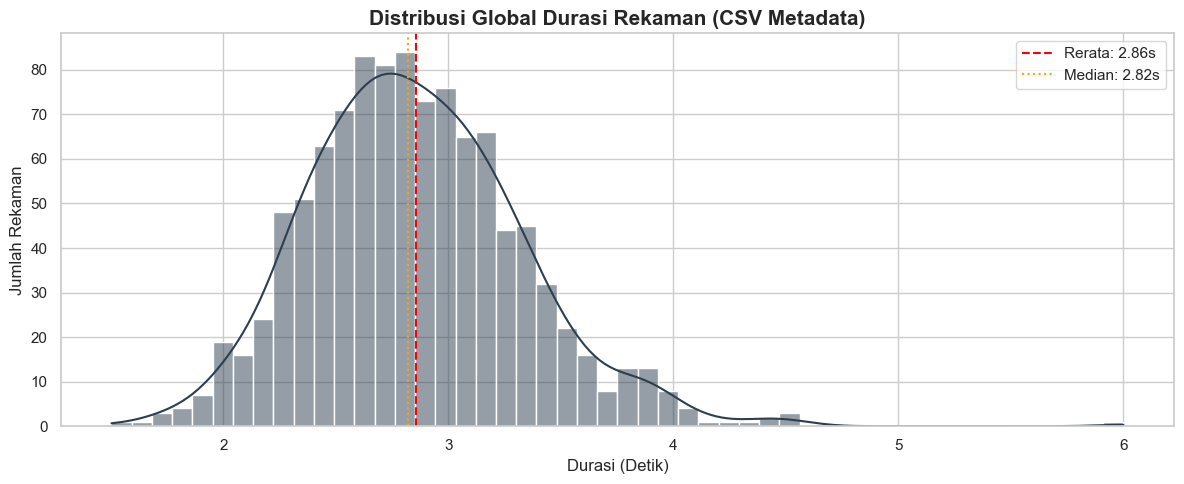

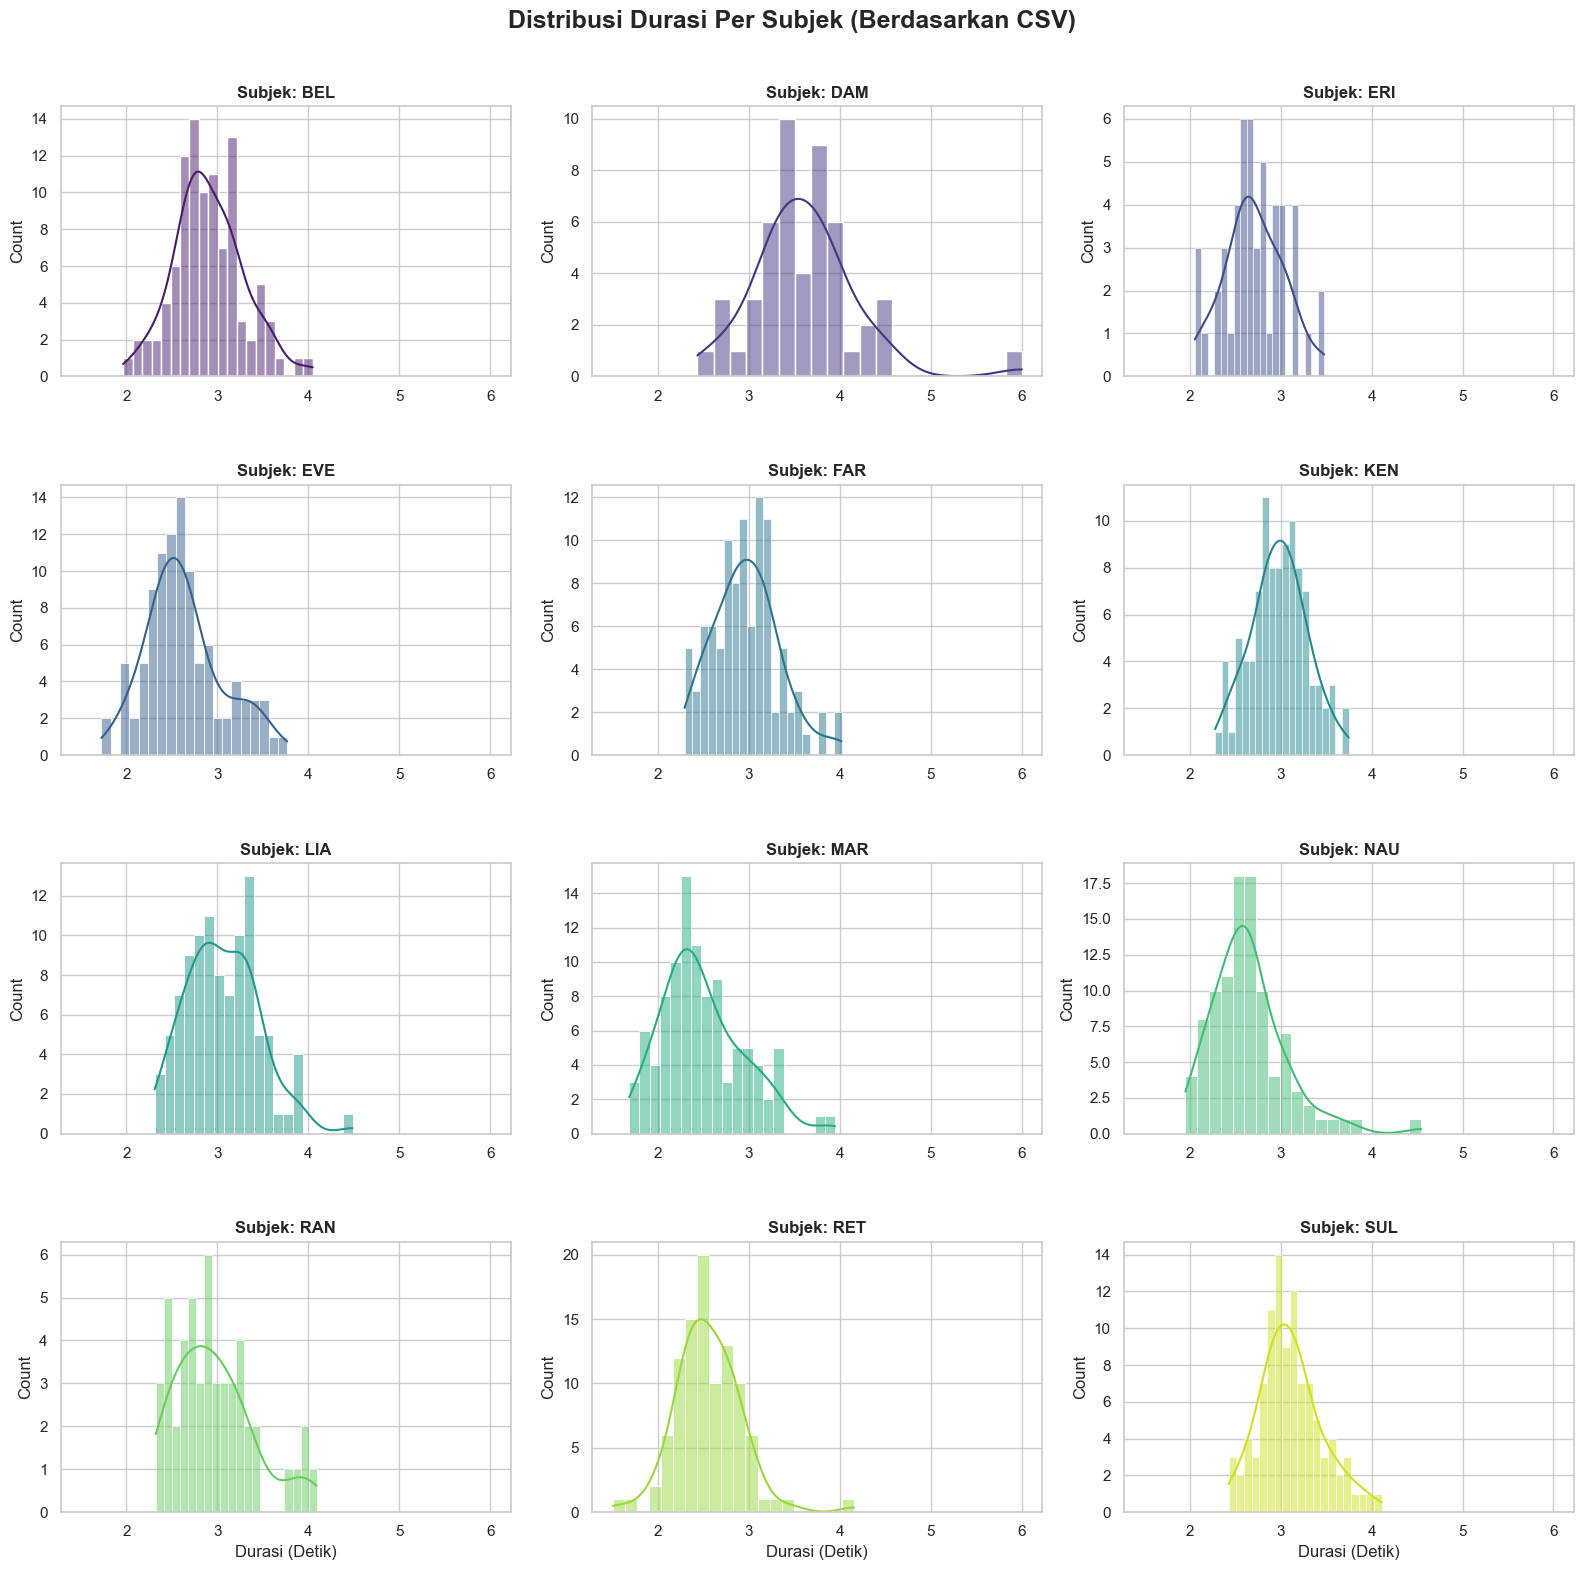

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math

print("=" * 80)
print(" ANALISIS DISTRIBUSI DURASI DARI METADATA CSV")
print("=" * 80)

# 1. Inisialisasi Path (Pastikan sesuai dengan notebook Anda)
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '../../../'))
cleaned_csv_path = os.path.join(project_root, 'dataset/cleaned_transcript_mapping.csv')
raw_data_path = os.path.join(project_root, 'dataset/raw')

# 2. Load Mapping Data
df_map = pd.read_csv(cleaned_csv_path)
subject_gender_map = dict(zip(df_map['subject'], df_map['gender']))

results = []

print("Mengekstrak durasi dari 1050 file CSV...")

# 3. Iterasi File
for index, row in df_map.iterrows():
    id_val = row['id']
    subject = row['subject']
    gender = row['gender']
    
    csv_folder = os.path.join(raw_data_path, gender, subject, 'csv')
    
    if not os.path.isdir(csv_folder):
        continue
        
    # Cari file dengan prefix ID dan suffix .bp.csv
    matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
    
    if matching_files:
        file_path = os.path.join(csv_folder, matching_files[0])
        
        try:
            # Baca baris pertama saja untuk metadata
            with open(file_path, 'r') as f:
                metadata = f.readline()
            
            # Gunakan RegEx untuk mencari start dan stop timestamp
            start_search = re.search(r"start timestamp:(\d+\.\d+)", metadata)
            stop_search = re.search(r"stop timestamp:(\d+\.\d+)", metadata)
            
            if start_search and stop_search:
                start_ts = float(start_search.group(1))
                stop_ts = float(stop_search.group(1))
                duration = stop_ts - start_ts
                
                results.append({
                    'id': id_val,
                    'subject': subject,
                    'duration': duration
                })
        except Exception as e:
            pass

df_duration = pd.DataFrame(results)

# ==========================================================
# 4. VISUALISASI GLOBAL
# ==========================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.histplot(data=df_duration, x='duration', kde=True, color='#2c3e50', bins=50)

plt.axvline(df_duration['duration'].mean(), color='red', linestyle='--', label=f"Rerata: {df_duration['duration'].mean():.2f}s")
plt.axvline(df_duration['duration'].median(), color='orange', linestyle=':', label=f"Median: {df_duration['duration'].median():.2f}s")

plt.title('Distribusi Global Durasi Rekaman (CSV Metadata)', fontsize=15, fontweight='bold')
plt.xlabel('Durasi (Detik)')
plt.ylabel('Jumlah Rekaman')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 5. VISUALISASI PER SUBJEK
# ==========================================================
unique_subjects = sorted(df_duration['subject'].unique())
cols = 3
rows = math.ceil(len(unique_subjects) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows), sharex=True)
axes = axes.flatten()

palette = sns.color_palette("viridis", len(unique_subjects))

for i, subj in enumerate(unique_subjects):
    subj_data = df_duration[df_duration['subject'] == subj]
    ax = axes[i]
    
    sns.histplot(data=subj_data, x='duration', kde=True, ax=ax, color=palette[i], bins=20)
    ax.set_title(f"Subjek: {subj}", fontweight='bold')
    ax.set_xlabel("Durasi (Detik)")
    ax.tick_params(labelbottom=True)

# Hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4)
fig.suptitle('Distribusi Durasi Per Subjek (Berdasarkan CSV)', fontsize=18, fontweight='bold')
plt.show()


 ANALISIS DISTRIBUSI AMPLITUDO EEG (SELURUH DATA)
Memuat seluruh data EEG dari file CSV... (Mohon tunggu, proses ini memakan memori)
Membuat visualisasi distribusi global per channel...


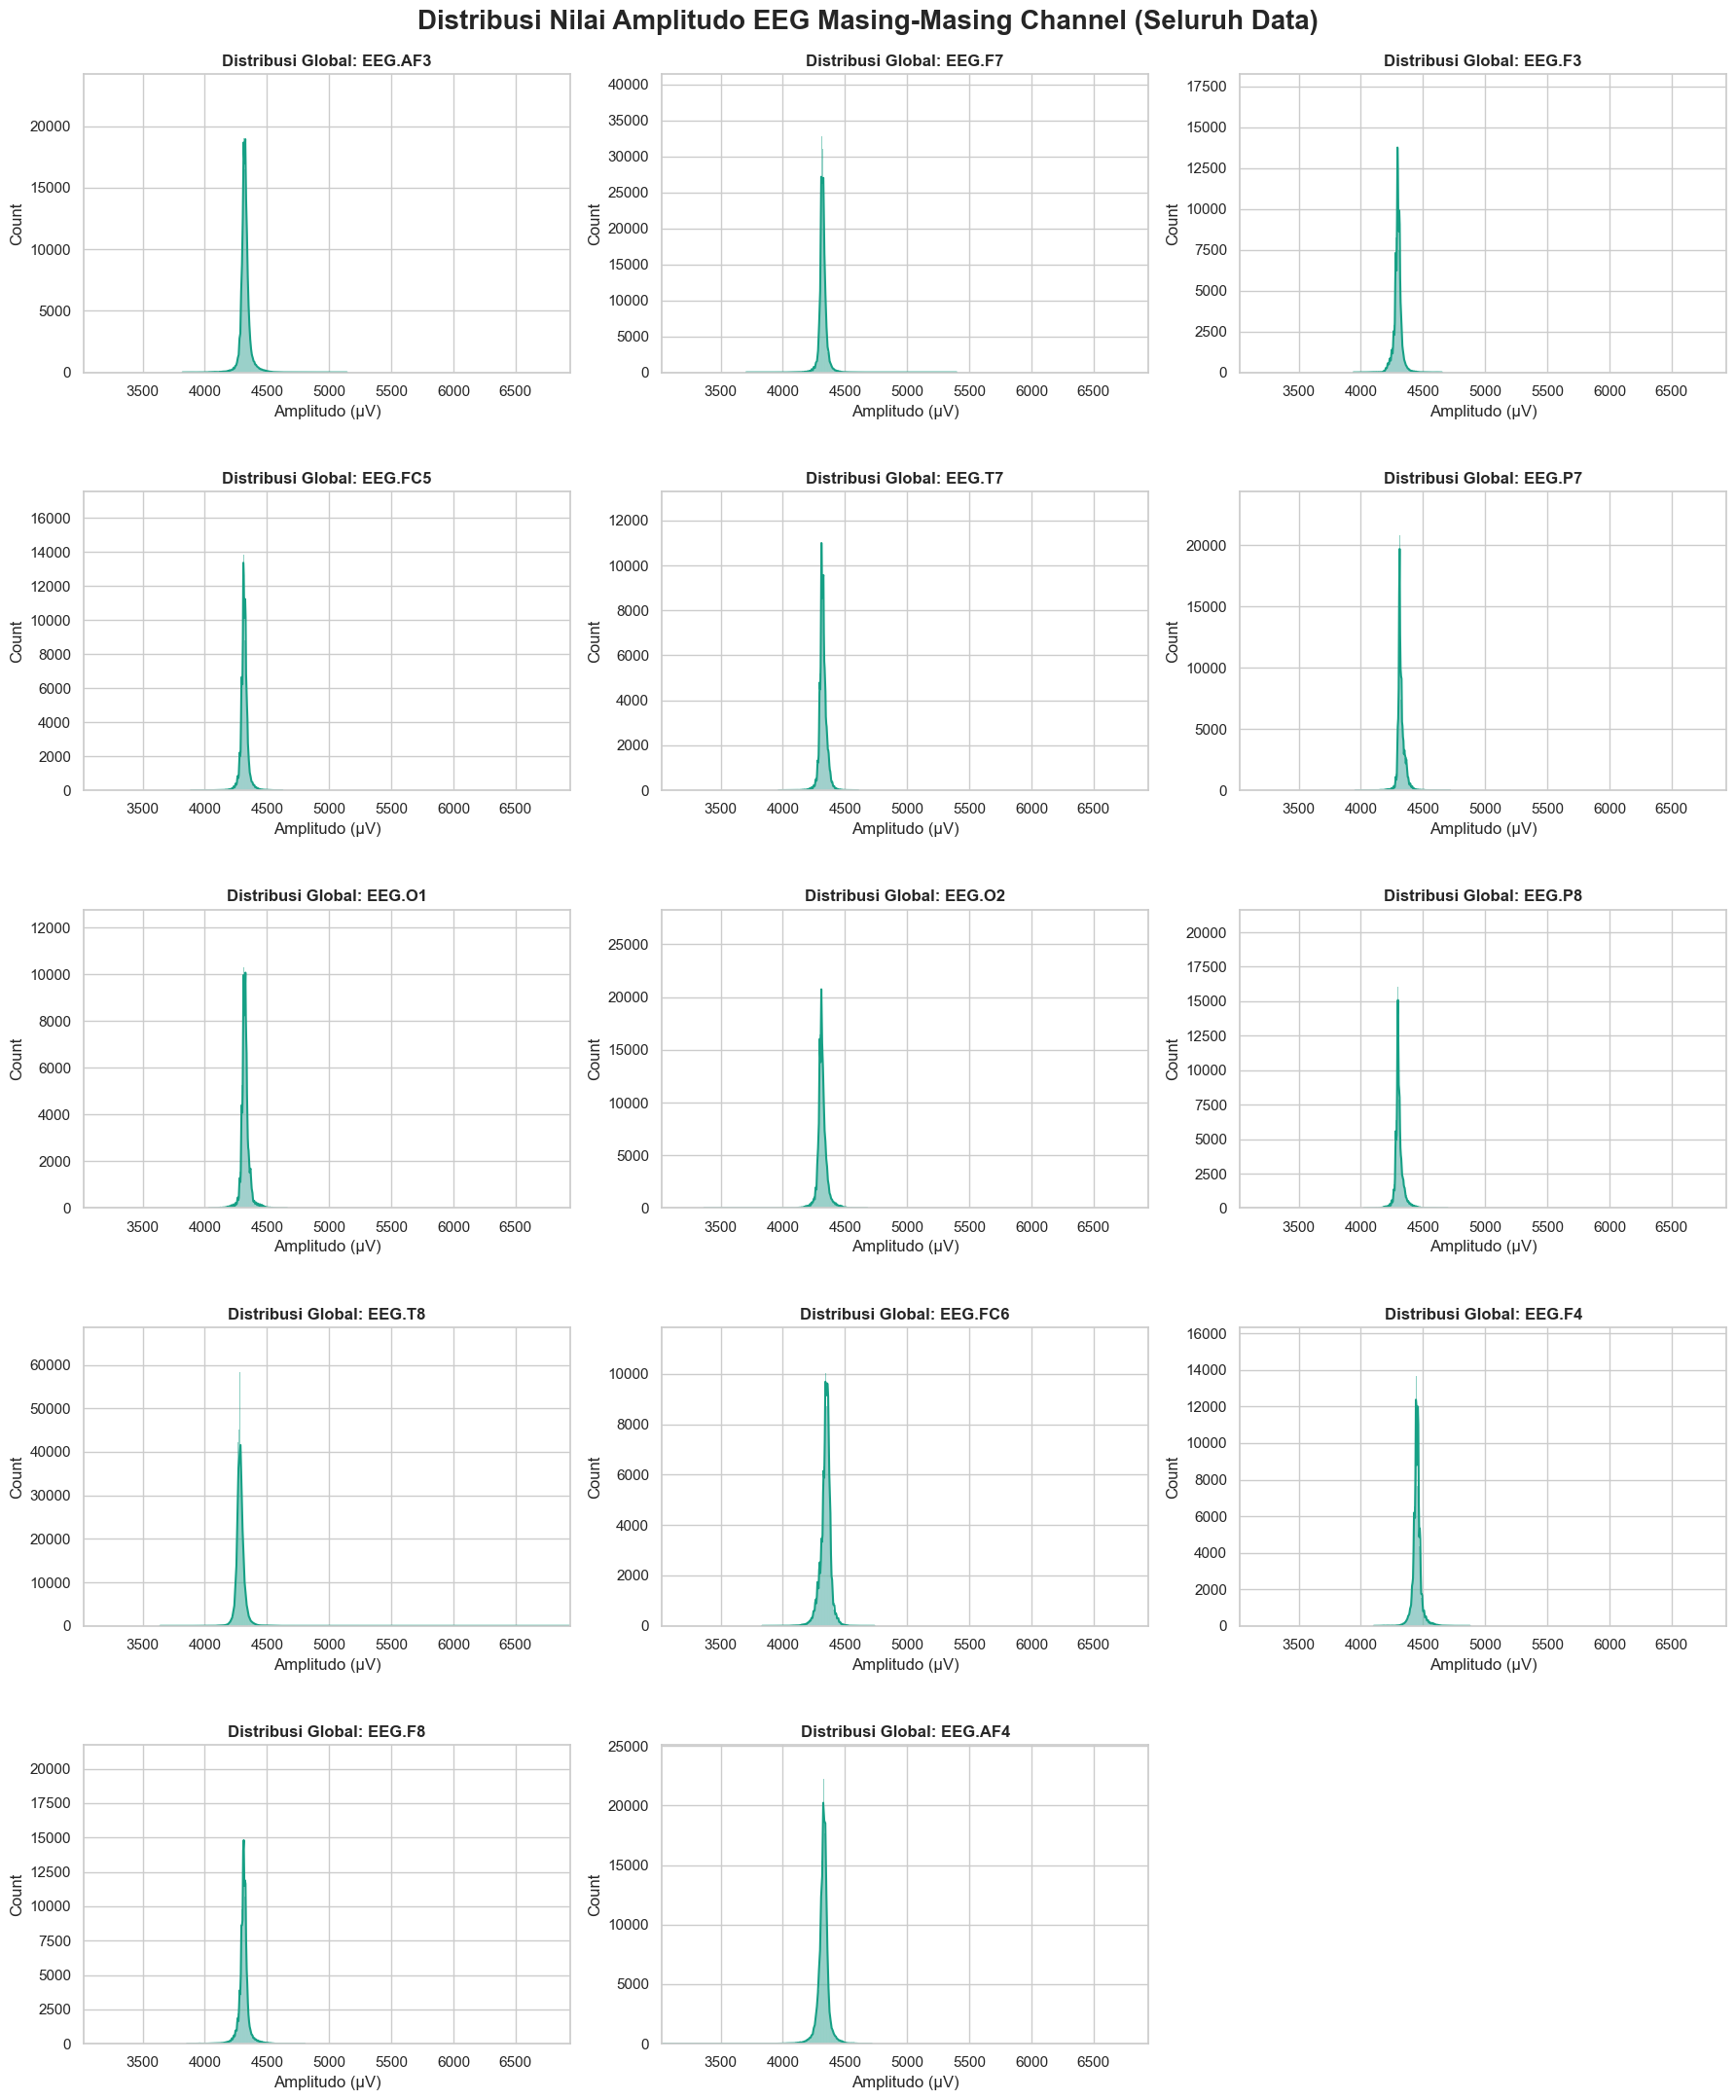

Membuat visualisasi distribusi per subjek...


/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


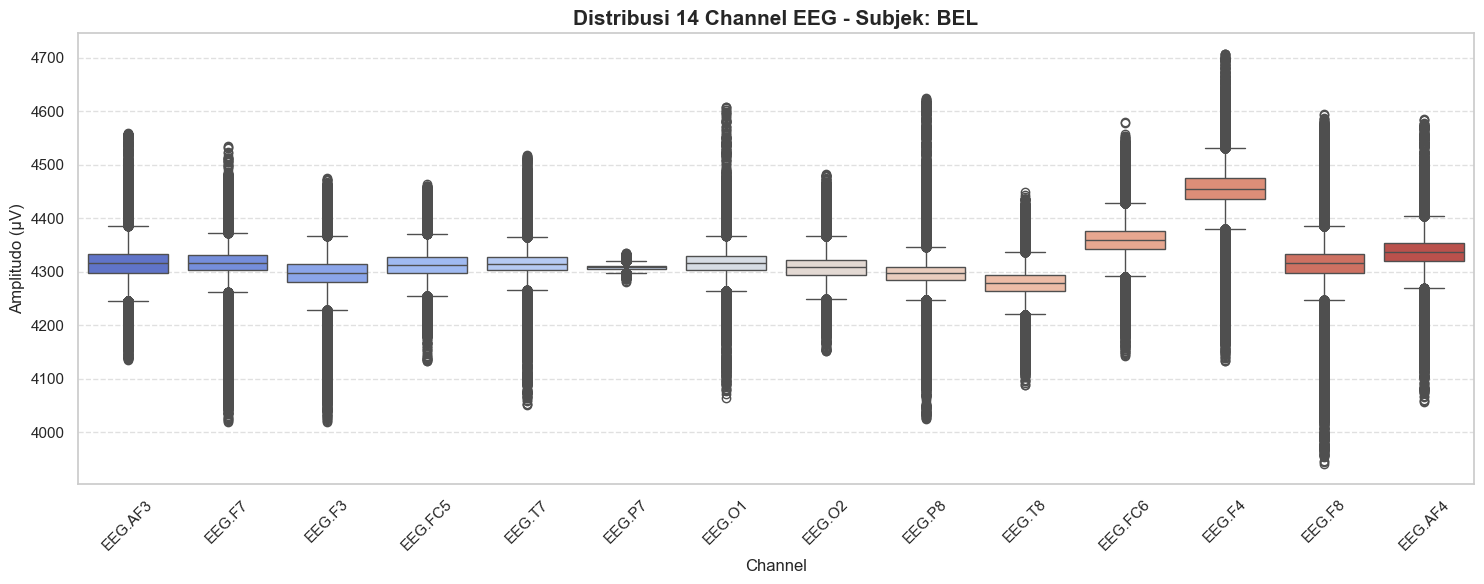

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


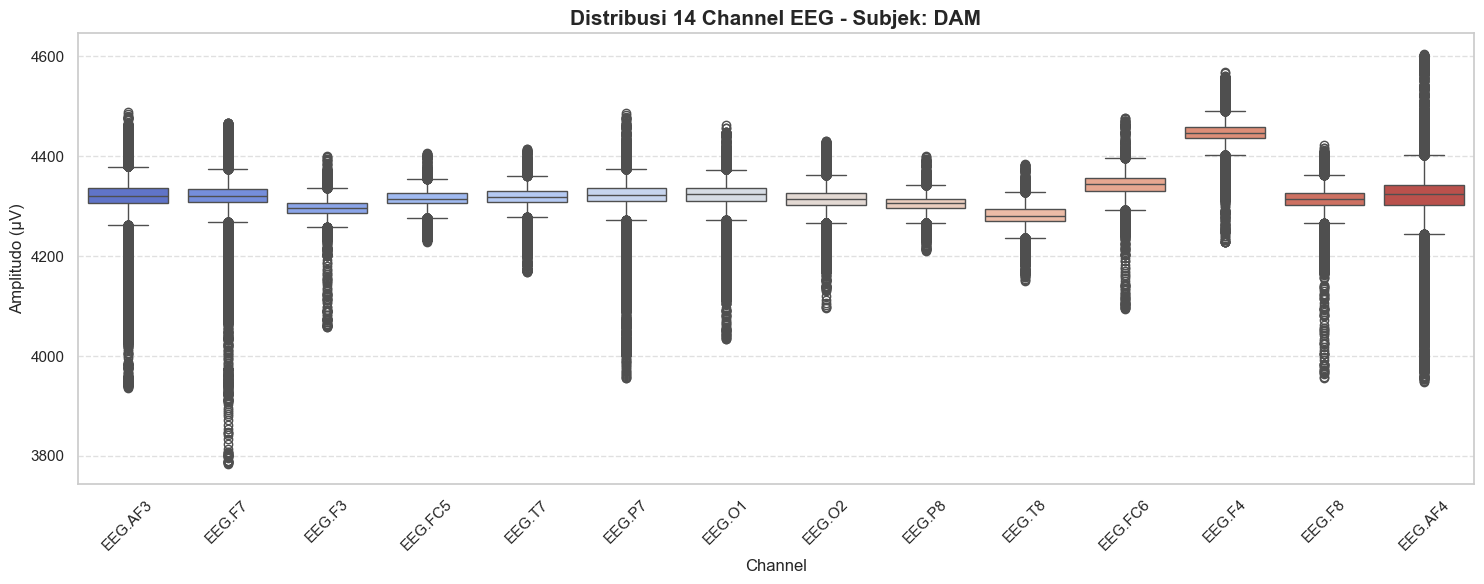

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


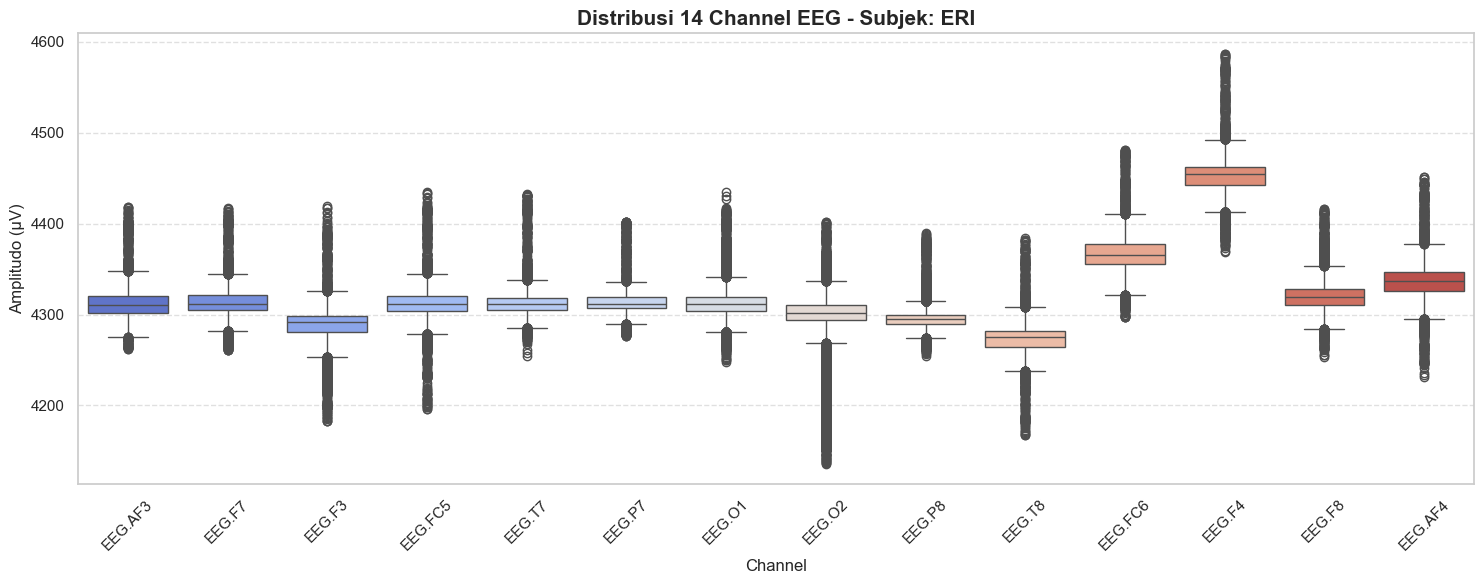

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


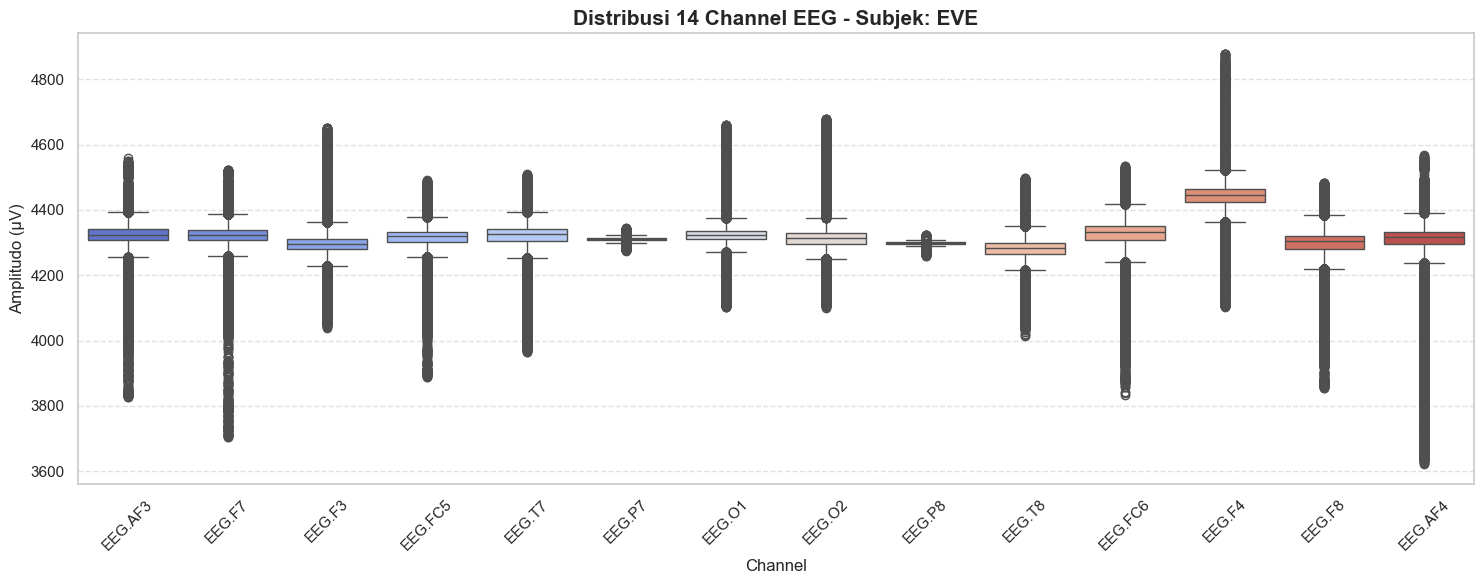

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


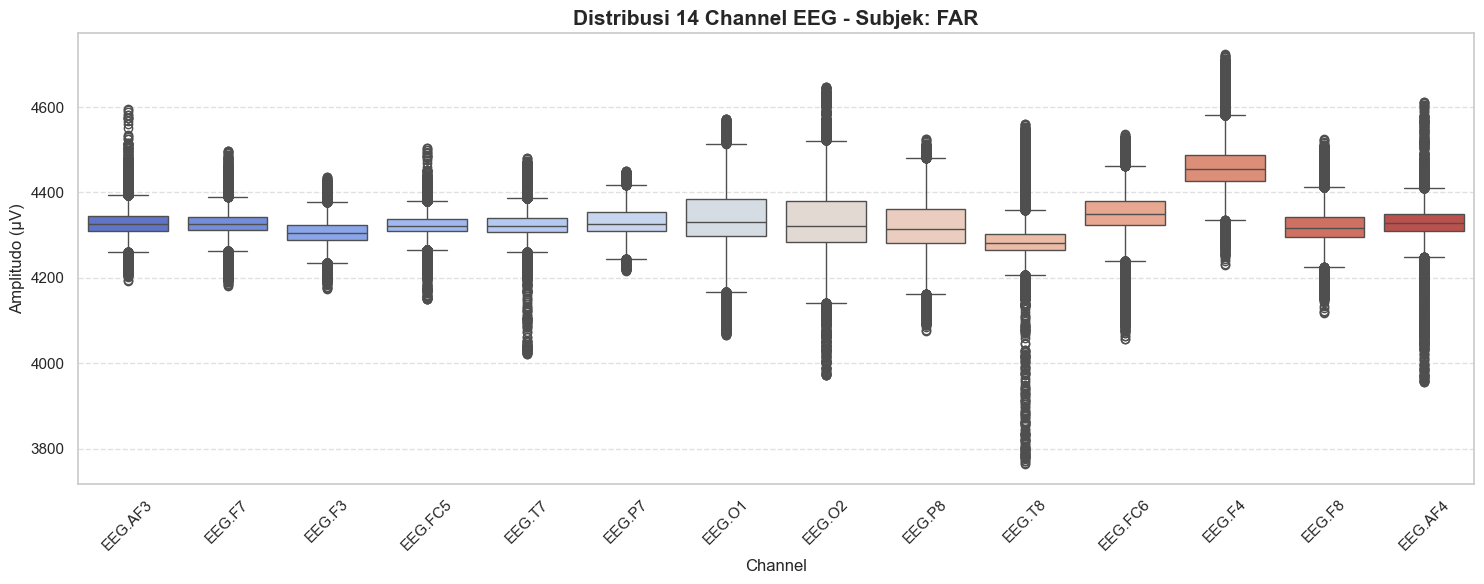

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


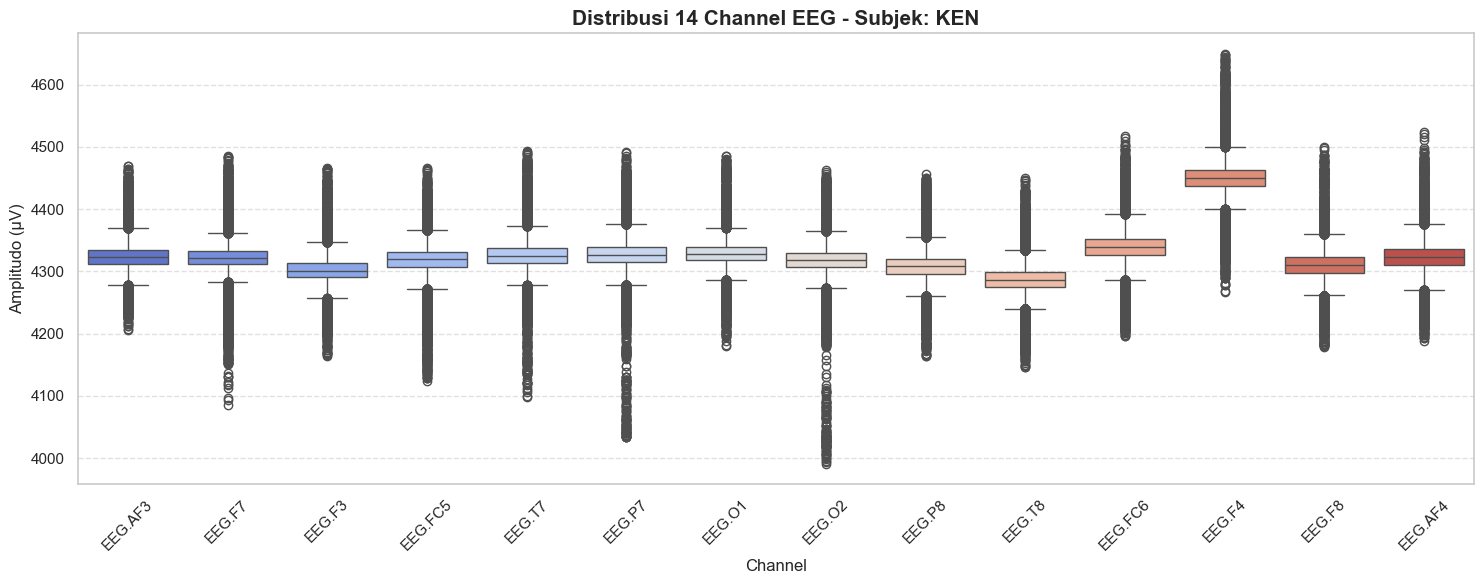

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


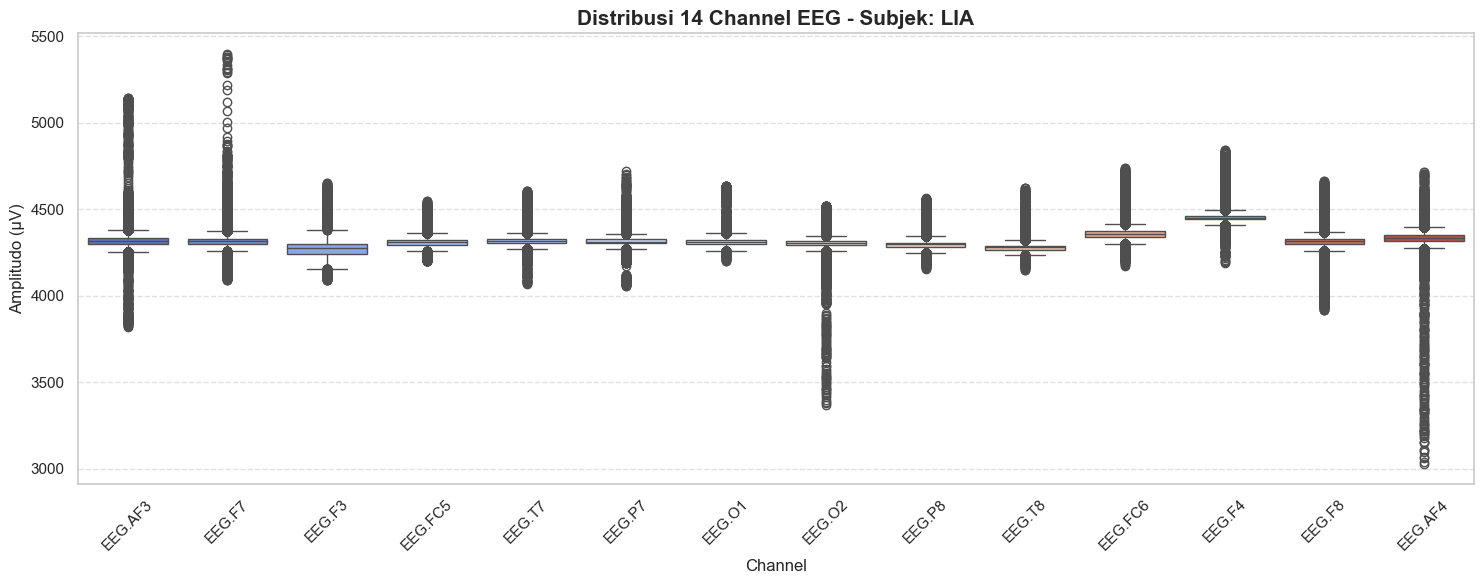

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


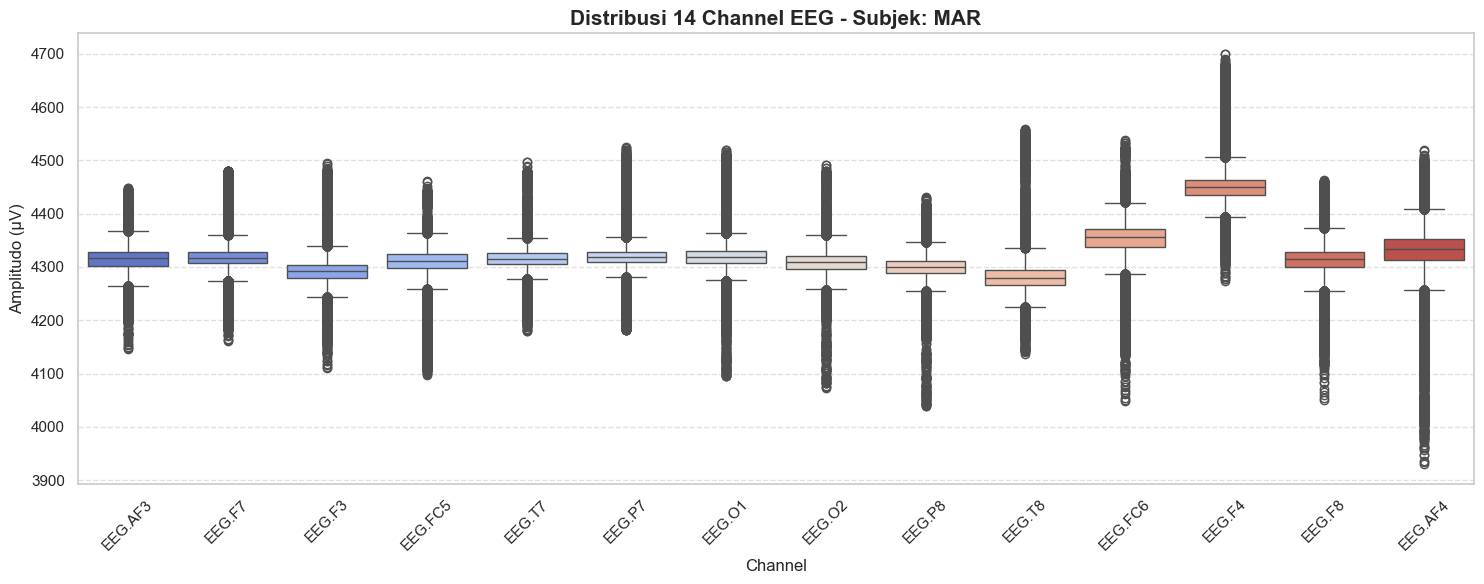

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


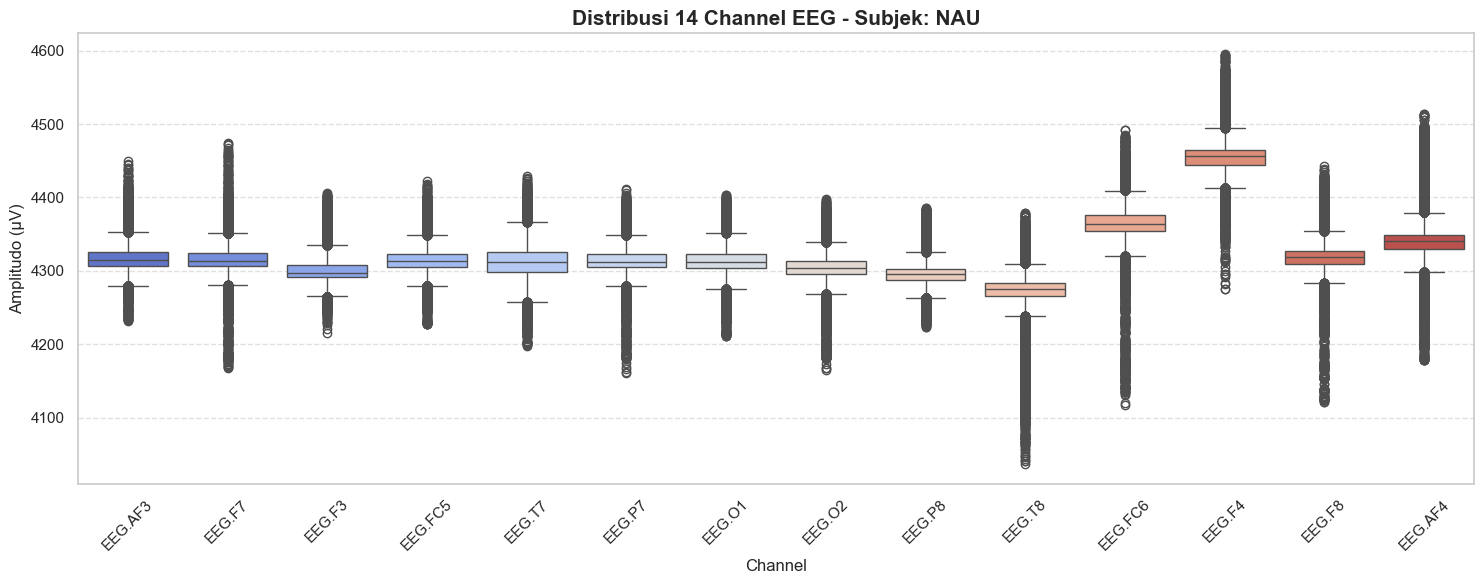

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


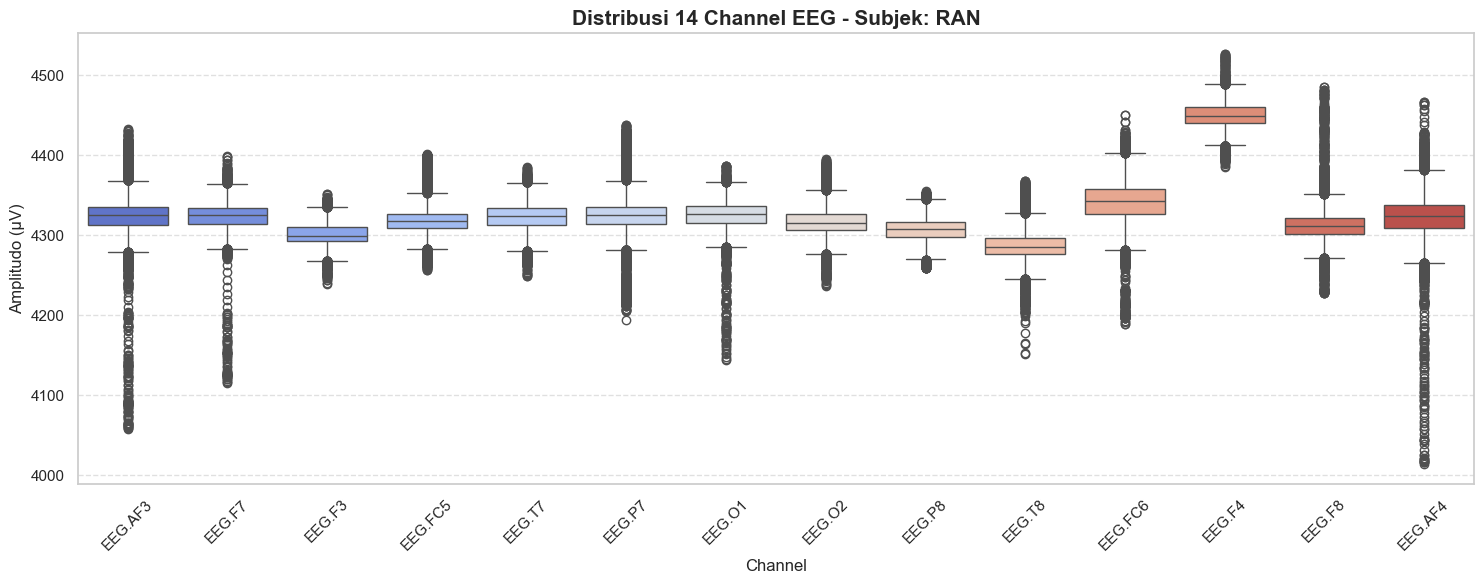

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


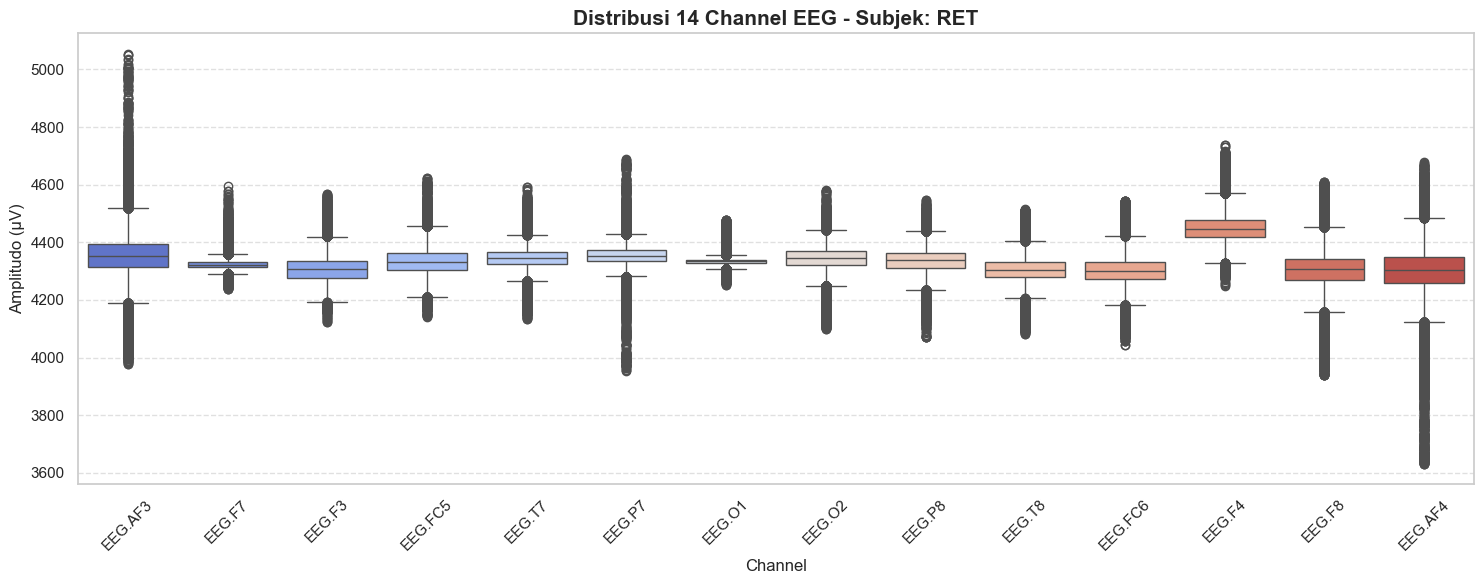

/var/folders/8c/nv_d5v_x5knfkn3qp5zpwgb80000gn/T/ipykernel_16234/2263450075.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')


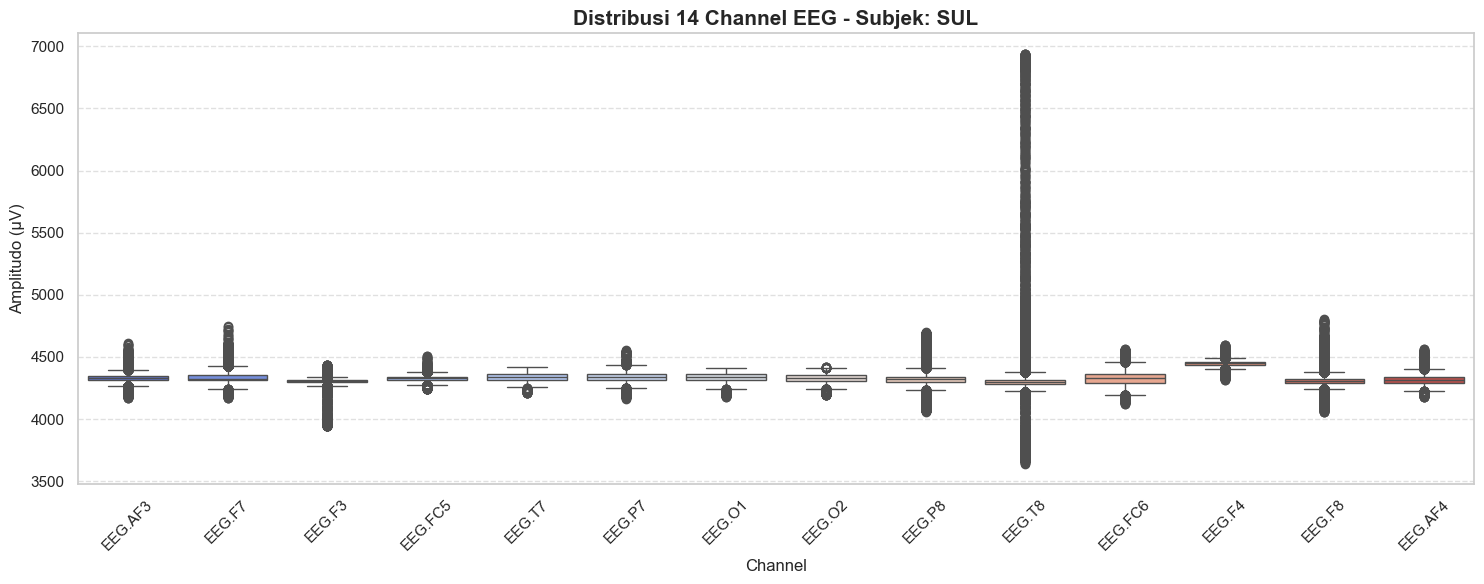

In [16]:
# ==========================================================
# 6. ANALISIS DISTRIBUSI NILAI AMPLITUDO EEG PER CHANNEL
# ==========================================================
print("\n" + "=" * 80)
print(" ANALISIS DISTRIBUSI AMPLITUDO EEG (SELURUH DATA)")
print("=" * 80)

# Daftar channel EEG standar Emotiv EPOC X
eeg_channels = [
    'EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7', 'EEG.O1', 
    'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4'
]

all_eeg_data = []

print("Memuat seluruh data EEG dari file CSV... (Mohon tunggu, proses ini memakan memori)")

for index, row in df_map.iterrows():
    id_val, subject, gender = row['id'], row['subject'], row['gender']
    csv_folder = os.path.join(raw_data_path, gender, subject, 'csv')
    
    if not os.path.isdir(csv_folder):
        continue
        
    matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
    
    if matching_files:
        file_path = os.path.join(csv_folder, matching_files[0])
        try:
            # Memuat hanya kolom EEG yang diperlukan (usecols) untuk efisiensi RAM
            # skiprows=1 karena file .bp.csv memiliki metadata di baris pertama
            df_temp = pd.read_csv(file_path, skiprows=1, usecols=lambda x: x in eeg_channels)
            
            # Tambahkan info subjek
            df_temp['subject'] = subject
            all_eeg_data.append(df_temp)
        except Exception as e:
            continue

# Gabungkan seluruh data menjadi satu DataFrame raksasa
df_all_eeg = pd.concat(all_eeg_data, ignore_index=True)

# Transformasi ke format Long-form (Melt) agar mudah divisualisasikan per channel
df_melted = df_all_eeg.melt(id_vars=['subject'], value_vars=eeg_channels, 
                            var_name='Channel', value_name='Amplitude')

# Pembersihan visual: Menghitung batas percentile untuk menghilangkan outlier ekstrem di plot
# (Hanya untuk tampilan agar grafik tidak gepeng, data asli tetap utuh di dataframe)
lower_limit = df_melted['Amplitude'].min()
upper_limit = df_melted['Amplitude'].max()

# ----------------------------------------------------------
# 7. VISUALISASI GLOBAL: DISTRIBUSI MASING-MASING CHANNEL
# ----------------------------------------------------------
print("Membuat visualisasi distribusi global per channel...")
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, ch in enumerate(eeg_channels):
    sns.histplot(data=df_melted[df_melted['Channel'] == ch], x='Amplitude', 
                 kde=True, ax=axes[i], color='#16a085', bins=1000)
    axes[i].set_title(f'Distribusi Global: {ch}', fontweight='bold', fontsize=12)
    axes[i].set_xlim(lower_limit, upper_limit)
    axes[i].set_xlabel("Amplitudo (μV)")

# Hapus subplot ke-15 (karena hanya ada 14 channel)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.4)
fig.suptitle('Distribusi Nilai Amplitudo EEG Masing-Masing Channel (Seluruh Data)', fontsize=20, fontweight='bold')
plt.show()

# ----------------------------------------------------------
# 8. VISUALISASI PER SUBJEK: DISTRIBUSI 14 CHANNEL
# ----------------------------------------------------------
print("Membuat visualisasi distribusi per subjek...")
subjects_list = sorted(df_melted['subject'].unique())

# Menggunakan Boxplot per subjek untuk melihat variansi 14 channel secara berdampingan
for subj in subjects_list:
    plt.figure(figsize=(15, 6))
    subj_data = df_melted[df_melted['subject'] == subj]
    
    sns.boxplot(data=subj_data, x='Channel', y='Amplitude', palette='coolwarm')
    
    plt.title(f'Distribusi 14 Channel EEG - Subjek: {subj}', fontsize=15, fontweight='bold')
    plt.ylabel('Amplitudo (μV)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()